# Agglomerative Clustering — Wholesale Customers
**Dataset:** UCI Wholesale Customers  
**Goal:** Segment customers based on spending patterns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

## 1. Load Data

In [2]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00292/Wholesale%20customers%20data.csv'
df = pd.read_csv(url)
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Columns: {df.columns.tolist()}')
df.head()

Shape: 440 rows x 8 columns
Columns: ['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


## 2. EDA

In [3]:
print('Data Types:')
print(df.dtypes)
print()
print('Missing Values:', df.isnull().sum().sum())
print('Duplicates:', df.duplicated().sum())
print()
print('Statistics:')
df.describe().round(2)

Data Types:
Channel             int64
Region              int64
Fresh               int64
Milk                int64
Grocery             int64
Frozen              int64
Detergents_Paper    int64
Delicassen          int64
dtype: object

Missing Values: 0
Duplicates: 0

Statistics:


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.00,440.00,440.00,440.00,440.00,440.00,440.00,440.00
mean,1.32,2.54,12000.30,5796.27,7951.28,3071.93,2881.49,1524.87
std,0.47,0.77,12647.33,7380.38,9503.16,4854.67,4767.85,2820.11
min,1.00,1.00,3.00,55.00,3.00,25.00,3.00,3.00
25%,1.00,2.00,3127.75,1533.00,2153.00,742.25,256.75,408.25
50%,1.00,3.00,8504.00,3627.00,4755.50,1526.00,816.50,965.50
75%,2.00,3.00,16933.75,7190.25,10655.75,3554.25,3922.00,1820.25
max,2.00,3.00,112151.00,73498.00,92780.00,60869.00,40827.00,47943.00


In [4]:
print('Channel Distribution:')
print(df['Channel'].value_counts())
print()
print('Region Distribution:')
print(df['Region'].value_counts())

Channel Distribution:
Channel
1    298
2    142
Name: count, dtype: int64

Region Distribution:
Region
3    316
1     77
2     47
Name: count, dtype: int64


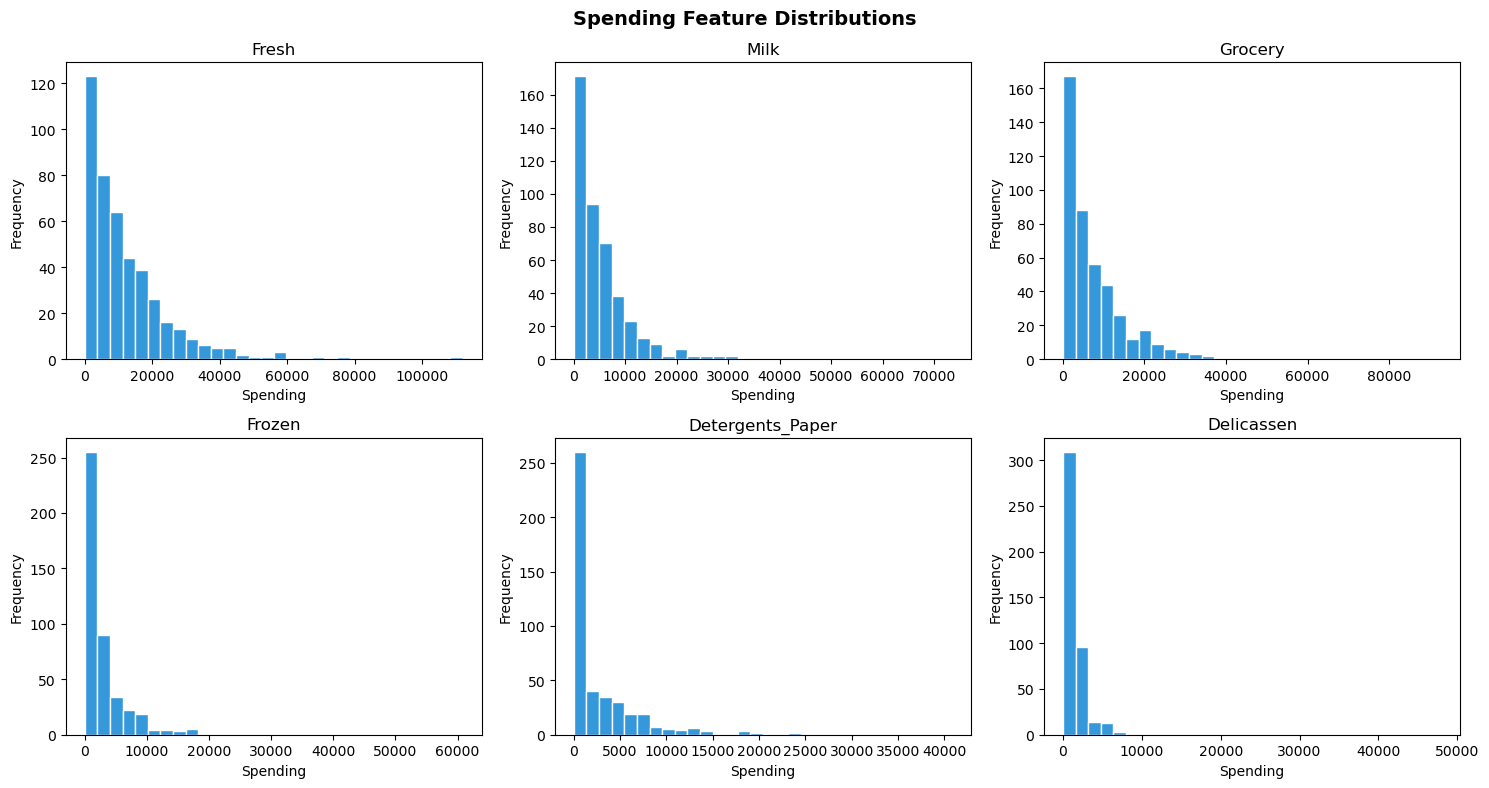

In [5]:
spending_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Spending Feature Distributions', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(spending_cols):
    axes[i].hist(df[col], bins=30, color='#3498db', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Spending')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

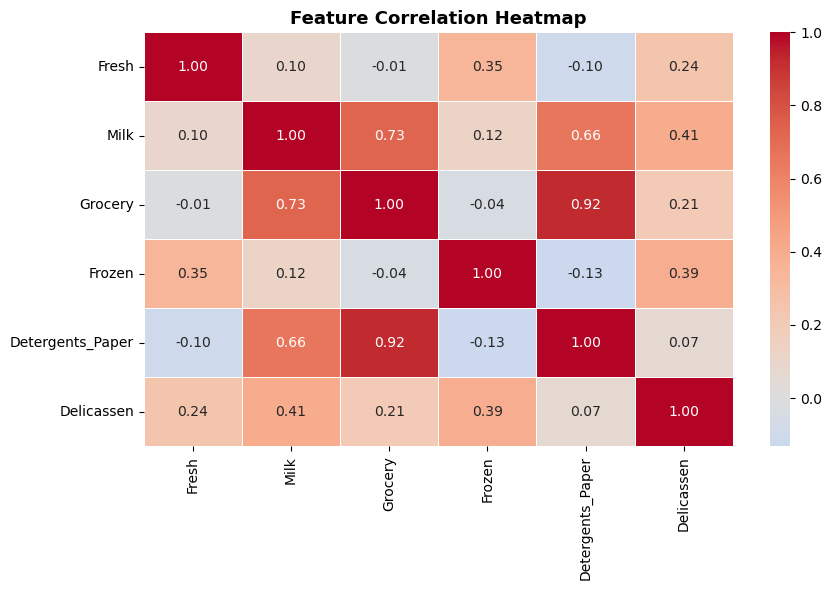

In [6]:
plt.figure(figsize=(9, 6))
sns.heatmap(df[spending_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Preprocessing

In [7]:
df_clean = df.drop(columns=['Channel', 'Region'])
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(f'Shape after cleaning: {df_clean.shape}')
print(f'Missing values: {df_clean.isnull().sum().sum()}')

# IQR capping
for col in df_clean.columns:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    df_clean[col] = df_clean[col].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)
print('Outliers capped using IQR.')

# Log transform (spending data is right-skewed)
df_log = np.log1p(df_clean)
print('Log transformation applied.')

# Standard scaling
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_log), columns=df_log.columns)
print('StandardScaler applied.')
print(f'Final shape: {df_scaled.shape}')

Shape after cleaning: (440, 6)
Missing values: 0
Outliers capped using IQR.
Log transformation applied.
StandardScaler applied.
Final shape: (440, 6)


## 4. Dendrogram — Find Optimal K

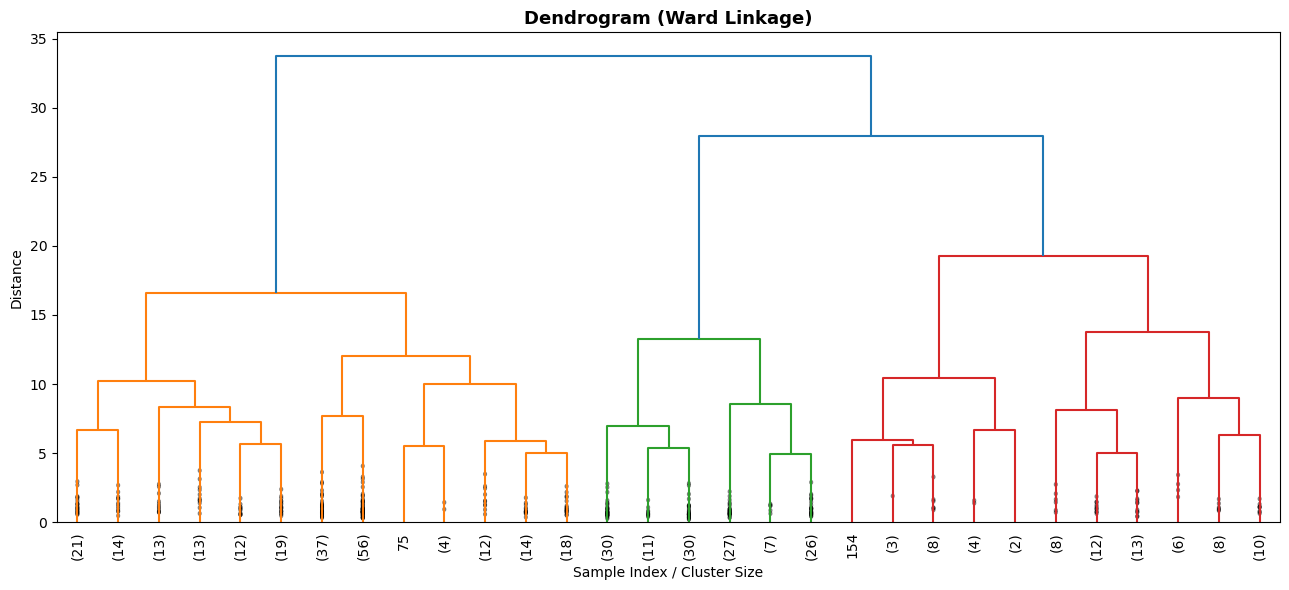

In [8]:
linkage_matrix = linkage(df_scaled, method='ward', metric='euclidean')

plt.figure(figsize=(13, 6))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=10, show_contracted=True)
plt.title('Dendrogram (Ward Linkage)', fontsize=13, fontweight='bold')
plt.xlabel('Sample Index / Cluster Size')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

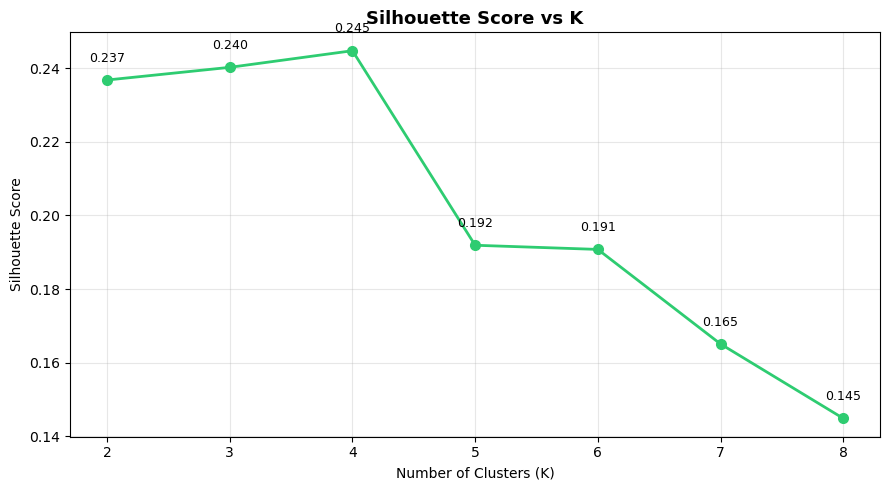

Best K = 4  (Silhouette = 0.2447)


In [9]:
sil_scores = {}
for k in range(2, 9):
    labels = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(df_scaled)
    sil_scores[k] = silhouette_score(df_scaled, labels)

ks   = list(sil_scores.keys())
sils = list(sil_scores.values())

plt.figure(figsize=(9, 5))
plt.plot(ks, sils, 'o-', color='#2ecc71', linewidth=2, markersize=7)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs K', fontsize=13, fontweight='bold')
plt.xticks(ks)
plt.grid(True, alpha=0.3)
for k, s in zip(ks, sils):
    plt.text(k, s + 0.005, f'{s:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

best_k = max(sil_scores, key=sil_scores.get)
print(f'Best K = {best_k}  (Silhouette = {sil_scores[best_k]:.4f})')

## 5. Fit Agglomerative Clustering

In [10]:
model = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
cluster_labels = model.fit_predict(df_scaled)

df_result = df_clean.copy()
df_result['Cluster'] = cluster_labels

print(f'Model: AgglomerativeClustering | Linkage: ward | K: {best_k}')
print(f'Silhouette Score: {silhouette_score(df_scaled, cluster_labels):.4f}')
print()
print('Cluster Sizes:')
print(df_result['Cluster'].value_counts().sort_index())

Model: AgglomerativeClustering | Linkage: ward | K: 4
Silhouette Score: 0.2447

Cluster Sizes:
Cluster
0    234
1     57
2    131
3     18
Name: count, dtype: int64


## 6. Cluster Analysis

In [11]:
print('Cluster Spending Profiles (Mean):')
cluster_means = df_result.groupby('Cluster').mean().round(1)
print(cluster_means.to_string())
print()
print('Cluster Spending Profiles (Median):')
cluster_medians = df_result.groupby('Cluster').median().round(1)
print(cluster_medians.to_string())

Cluster Spending Profiles (Mean):
           Fresh    Milk  Grocery  Frozen  Detergents_Paper  Delicassen
Cluster                                                                
0        11736.5  2507.9   3035.3  2724.7             626.0       953.4
1         4751.5  8019.3  13363.3   546.6            5579.8      1003.1
2        15039.6  8821.5  12441.2  3208.5            4337.5      2086.5
3          553.4  1211.9   4569.3   782.2            1110.9       208.4

Cluster Spending Profiles (Median):
           Fresh    Milk  Grocery  Frozen  Detergents_Paper  Delicassen
Cluster                                                                
0         9497.5  1896.0   2418.5  1975.5             328.5       711.0
1         1989.0  7555.0  11757.0   287.0            5611.0       666.0
2        11908.0  7209.0  10817.0  2221.0            3891.0      1894.0
3          423.5   908.5   2138.0   305.0             203.5       129.5


## 7. Visualizations

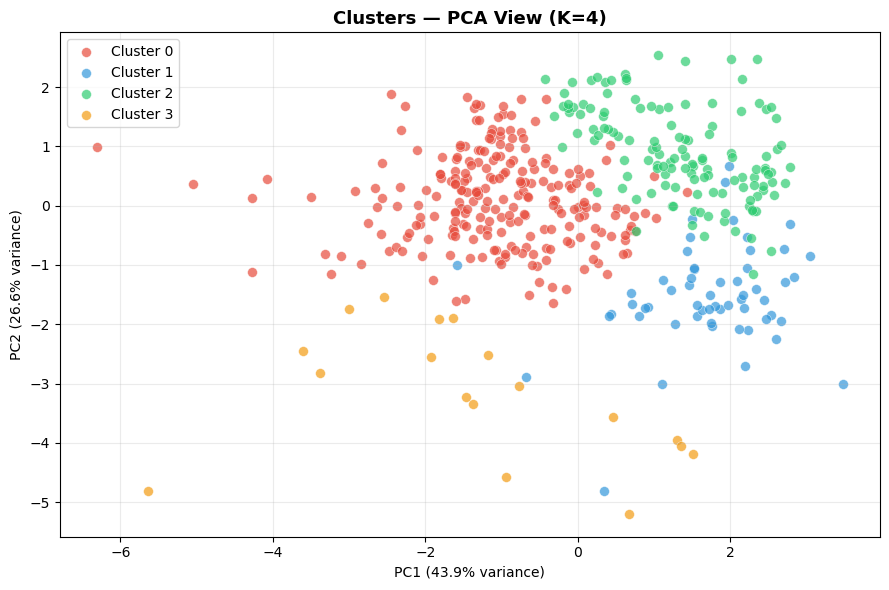

In [12]:
# PCA scatter plot
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

palette = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

plt.figure(figsize=(9, 6))
for cl in sorted(df_result['Cluster'].unique()):
    mask = cluster_labels == cl
    plt.scatter(df_pca[mask, 0], df_pca[mask, 1],
                color=palette[cl], label=f'Cluster {cl}',
                s=50, alpha=0.7, edgecolors='white', linewidths=0.4)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title(f'Clusters — PCA View (K={best_k})', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

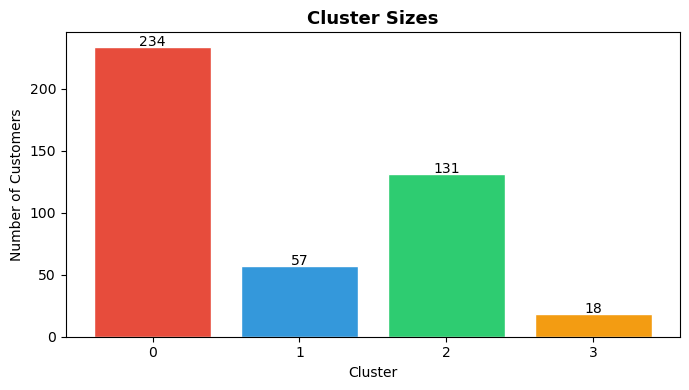

In [13]:
# Cluster size bar chart
cluster_counts = df_result['Cluster'].value_counts().sort_index()

plt.figure(figsize=(7, 4))
bars = plt.bar(cluster_counts.index, cluster_counts.values,
               color=[palette[i] for i in cluster_counts.index],
               edgecolor='white')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.title('Cluster Sizes', fontsize=13, fontweight='bold')
plt.xticks(cluster_counts.index)
for bar, val in zip(bars, cluster_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(val), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

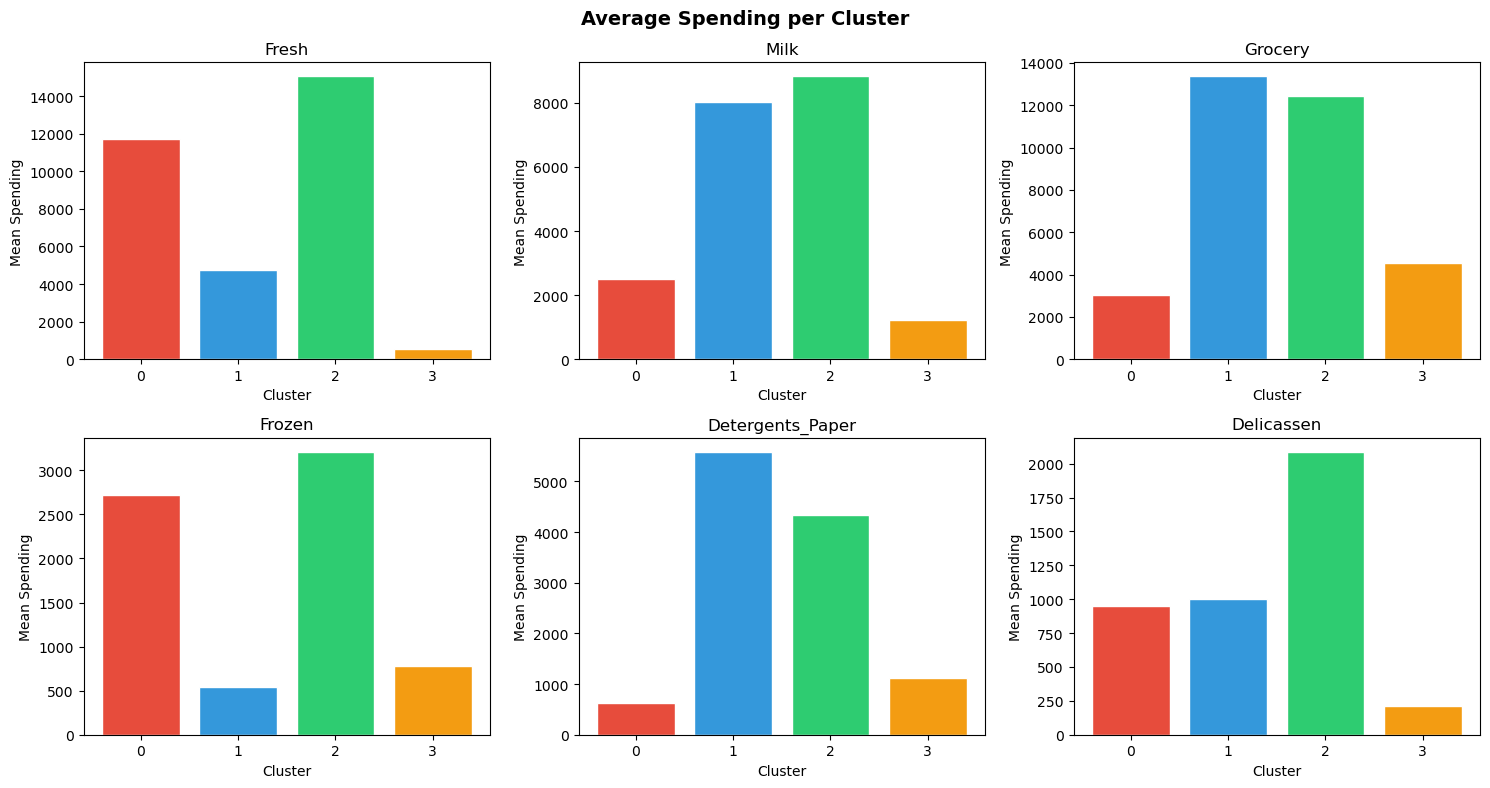

In [14]:
# Average spending per cluster
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Average Spending per Cluster', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(spending_cols):
    cl_means = df_result.groupby('Cluster')[col].mean()
    axes[i].bar(cl_means.index, cl_means.values,
                color=[palette[c] for c in cl_means.index],
                edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel('Mean Spending')
    axes[i].set_xticks(cl_means.index)

plt.tight_layout()
plt.show()